In [1]:
# CELL 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Libraries imported successfully!")


Libraries imported successfully!


In [2]:
# CELL 2: Create Loan Dataset
np.random.seed(42)
n = 500

data = {
    'Gender': np.random.choice(['Male', 'Female'], n),
    'Married': np.random.choice(['Yes', 'No'], n),
    'Education': np.random.choice(['Graduate', 'Not Graduate'], n),
    'Self_Employed': np.random.choice(['Yes', 'No'], n),
    'ApplicantIncome': np.random.randint(2000, 15000, n),
    'CoapplicantIncome': np.random.randint(0, 8000, n),
    'LoanAmount': np.random.randint(50, 500, n),
    'Loan_Amount_Term': np.random.choice([120, 180, 240, 360], n),
    'Credit_History': np.random.choice([0, 1], n, p=[0.2, 0.8]),
    'Property_Area': np.random.choice(['Urban', 'Rural', 'Semiurban'], n),
    'Loan_Status': np.random.choice(['Y', 'N'], n, p=[0.7, 0.3])
}

df = pd.DataFrame(data)
print("Dataset Shape:", df.shape)
print(df.head())


Dataset Shape: (500, 11)
   Gender Married     Education Self_Employed  ApplicantIncome  \
0    Male     Yes  Not Graduate           Yes             9982   
1  Female     Yes      Graduate            No             6107   
2    Male     Yes      Graduate            No             3341   
3    Male      No      Graduate           Yes            13855   
4    Male     Yes      Graduate           Yes            10407   

   CoapplicantIncome  LoanAmount  Loan_Amount_Term  Credit_History  \
0               7867         118               240               1   
1               4969         224               360               0   
2               4109          98               360               1   
3               5066         157               240               1   
4               7121         275               360               1   

  Property_Area Loan_Status  
0         Urban           Y  
1         Rural           N  
2         Urban           Y  
3         Urban           Y  
4      

In [3]:
# CELL 3: Data Preprocessing
print("Missing Values:\n", df.isnull().sum())

# Label Encoding
le = LabelEncoder()
cols = ['Gender','Married','Education','Self_Employed','Property_Area','Loan_Status']
for col in cols:
    df[col] = le.fit_transform(df[col])

print("\nAfter Encoding:")
print(df.head())

Missing Values:
 Gender               0
Married              0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

After Encoding:
   Gender  Married  Education  Self_Employed  ApplicantIncome  \
0       1        1          1              1             9982   
1       0        1          0              0             6107   
2       1        1          0              0             3341   
3       1        0          0              1            13855   
4       1        1          0              1            10407   

   CoapplicantIncome  LoanAmount  Loan_Amount_Term  Credit_History  \
0               7867         118               240               1   
1               4969         224               360               0   
2               4109          98               360               1   
3               5066         

In [4]:
# CELL 4: Train/Test Split & Model
X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(f"Model Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Model Accuracy: 65.00%

Classification Report:
               precision    recall  f1-score   support

           0       0.29      0.18      0.22        28
           1       0.72      0.83      0.77        72

    accuracy                           0.65       100
   macro avg       0.51      0.51      0.50       100
weighted avg       0.60      0.65      0.62       100



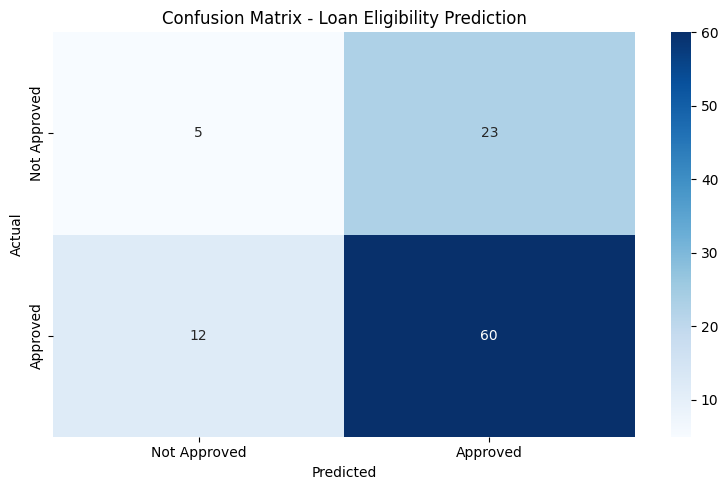

Plot 1 saved!


In [5]:
# CELL 5: Confusion Matrix
plt.figure(figsize=(8, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Approved', 'Approved'],
            yticklabels=['Not Approved', 'Approved'])
plt.title('Confusion Matrix - Loan Eligibility Prediction')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('loan_confusion_matrix.png')
plt.show()
print("Plot 1 saved!")

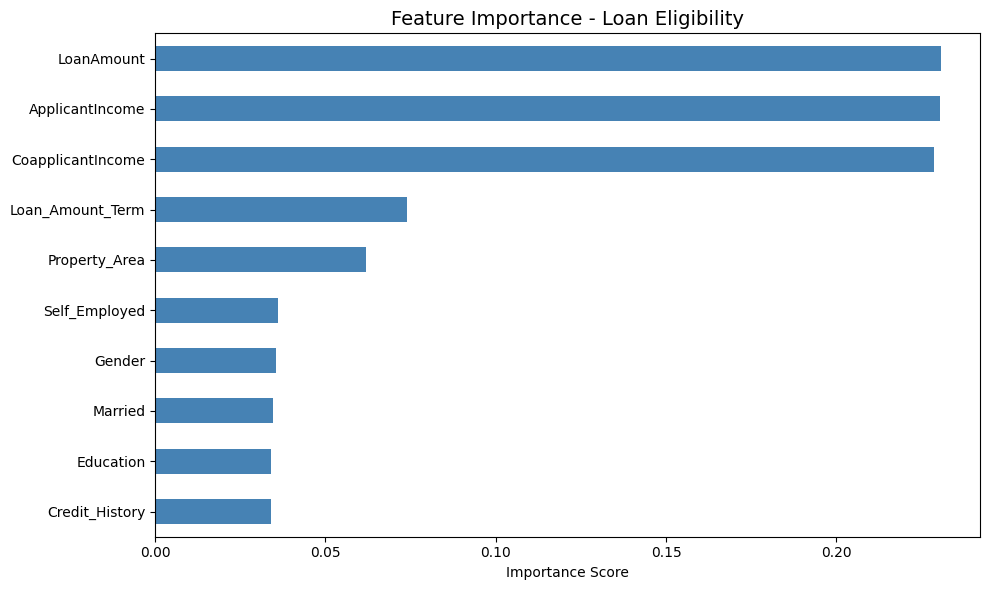

Plot 2 saved!


In [6]:
# CELL 6: Feature Importance
plt.figure(figsize=(10, 6))
feat_imp = pd.Series(model.feature_importances_, index=X.columns)
feat_imp.sort_values().plot(kind='barh', color='steelblue')
plt.title('Feature Importance - Loan Eligibility', fontsize=14)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()
print("Plot 2 saved!")

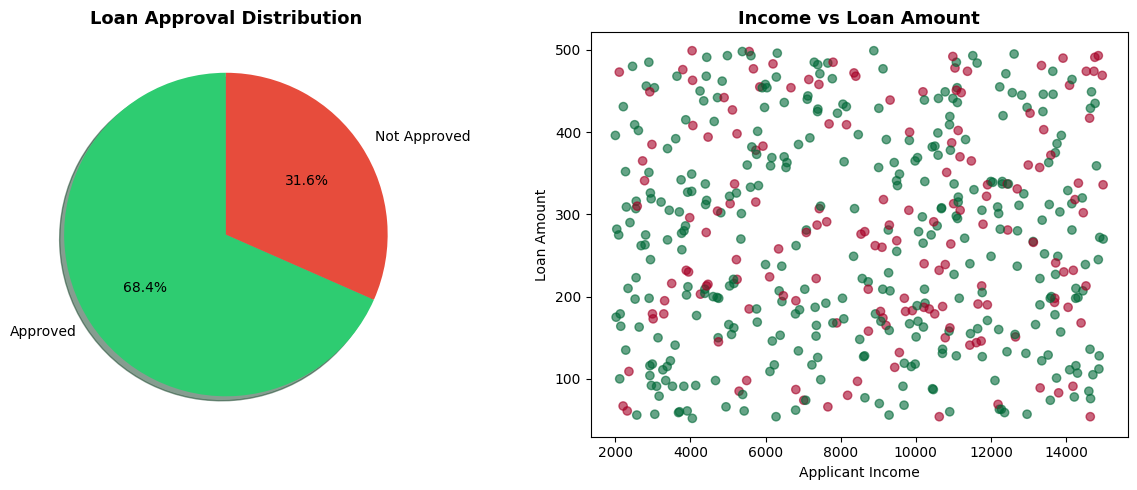

Plot 3 saved!


In [7]:
# CELL 7: Loan Approval Distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pie Chart
status = df['Loan_Status'].value_counts()
axes[0].pie(status, labels=['Approved', 'Not Approved'],
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'],
            shadow=True, startangle=90)
axes[0].set_title('Loan Approval Distribution', fontsize=13, fontweight='bold')

# Income vs Loan Amount
axes[1].scatter(df['ApplicantIncome'], df['LoanAmount'],
                c=df['Loan_Status'], cmap='RdYlGn', alpha=0.6)
axes[1].set_title('Income vs Loan Amount', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Applicant Income')
axes[1].set_ylabel('Loan Amount')

plt.tight_layout()
plt.savefig('loan_distribution.png')
plt.show()
print("Plot 3 saved!")

In [8]:
# CELL 8: Key Insights
print("=" * 50)
print("KEY INSIGHTS - Loan Eligibility Prediction")
print("=" * 50)
print(f"Total Applications: {len(df)}")
print(f"Approved Loans: {(df['Loan_Status']==1).sum()}")
print(f"Rejected Loans: {(df['Loan_Status']==0).sum()}")
print(f"Approval Rate: {(df['Loan_Status']==1).mean()*100:.1f}%")
print(f"\nModel Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")
print(f"Top Feature: {feat_imp.idxmax()} ({feat_imp.max():.3f})")

KEY INSIGHTS - Loan Eligibility Prediction
Total Applications: 500
Approved Loans: 342
Rejected Loans: 158
Approval Rate: 68.4%

Model Accuracy: 65.00%
Top Feature: LoanAmount (0.231)


/tmp/ipykernel_6811/1988597049.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Loan_Status_Label', y='ApplicantIncome',


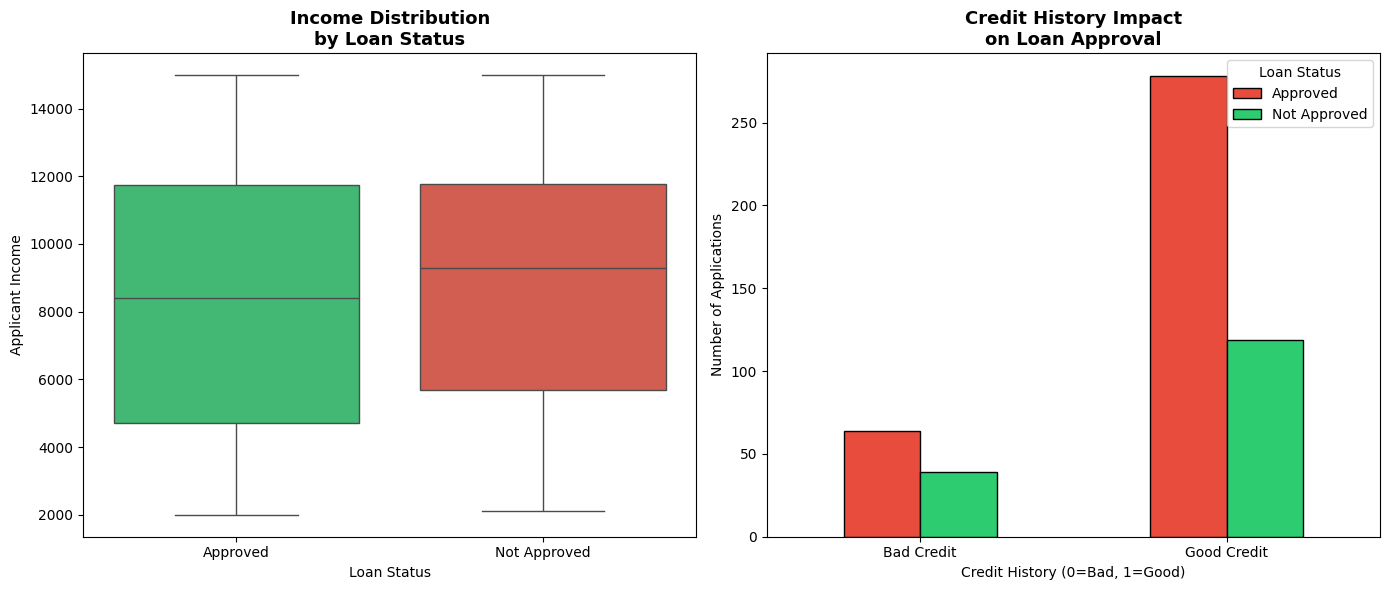

Elegant plots saved!


In [9]:
# CELL 9: Extra Elegant Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Income Distribution by Loan Status
df['Loan_Status_Label'] = df['Loan_Status'].map({1: 'Approved', 0: 'Not Approved'})
sns.boxplot(x='Loan_Status_Label', y='ApplicantIncome',
            data=df, palette={'Approved':'#2ecc71','Not Approved':'#e74c3c'},
            ax=axes[0])
axes[0].set_title('Income Distribution\nby Loan Status', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Loan Status')
axes[0].set_ylabel('Applicant Income')

# Plot 2: Credit History Impact
credit = df.groupby(['Credit_History','Loan_Status_Label']).size().unstack()
credit.plot(kind='bar', ax=axes[1],
            color=['#e74c3c','#2ecc71'], edgecolor='black')
axes[1].set_title('Credit History Impact\non Loan Approval', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Credit History (0=Bad, 1=Good)')
axes[1].set_ylabel('Number of Applications')
axes[1].set_xticklabels(['Bad Credit','Good Credit'], rotation=0)
axes[1].legend(title='Loan Status')

plt.tight_layout()
plt.savefig('elegant_loan_analysis.png', dpi=150)
plt.show()
print("Elegant plots saved!")